in this notebook we will have a look at potiential reasons why restaurants left and how we can bring them back

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
def load_data(table):
    df = pd.read_csv(f'rpc_18_inputs_for_participants//rpc_18_inputs_for_participants//RPC_18_Datasets//{table}.csv')
    return df
def save_data(df,name):
    df.to_csv(f'rpc_18_inputs_for_participants//rpc_18_inputs_for_participants//RPC_18_Datasets//{name}.csv',index=False)
    

In [6]:
restaurant = load_data('restaurant_corrected')
restaurant.drop(columns=['Unnamed: 0'], inplace=True)
restaurant.head()

,restaurant_id,restaurant_name,city,cuisine_type,partner_type,avg_prep_time_min,is_active
0,REST12962,Flavours of Sweets Palace,Bengaluru,Chinese,Restaurant,26-40,N
1,REST14069,Royal Biryani Darbar,Ahmedabad,Fast Food,Restaurant,16-25,Y
2,REST08622,Spicy Wraps Point,Mumbai,North Indian,Restaurant,16-25,Y
3,REST19745,Delhi Express Palace,Ahmedabad,Pizza,Cloud Kitchen,16-25,Y
4,REST02383,Namma Mess Delight,Mumbai,Healthy,Restaurant,26-40,Y


In [39]:
orders = load_data('fact_orders')
orders.head()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N


In [9]:
ratings = load_data('fact_ratings')
ratings.head()

,order_id,customer_id,restaurant_id,rating,review_text,review_timestamp,sentiment_score
0,ORD202501023439,CUST181110,REST08622,4.5,Super fast delivery,01-01-2025 15:00,0.75
1,ORD202501019281,CUST179306,REST14069,4.5,Great taste!,01-01-2025 15:00,0.75
2,ORD202501018036,CUST093042,REST13907,5.0,Super fast delivery,01-01-2025 14:03,1.00
3,ORD202501007724,CUST110825,REST08451,4.0,Tasty but a bit late,01-01-2025 14:06,0.50
4,ORD202501002349,CUST181669,REST00225,4.4,Satisfied overall,01-01-2025 14:06,0.70


In [13]:
delivery_performance = load_data('fact_delivery_performance_enhanced')
delivery_performance.drop(columns=['Unnamed: 0'], inplace=True)
delivery_performance.head()

,order_id,actual_delivery_time_mins,expected_delivery_time_mins,distance_km,delay_per_km
0,ORD202501023439,31,31,6.4,0.000000
1,ORD202501012051,46,42,1.9,2.105263
2,ORD202501019281,25,31,6.2,-0.967742
3,ORD202501000124,29,41,6.2,-1.935484
4,ORD202501006518,37,41,2.4,-1.666667


lets consider if there is relation btw last few orders status and restaurant churn

is there relation btw cancellatio rate and churn (last 10 orders)

In [40]:
# in orders is_cancelled column replace Y with 1 no with 0
orders['is_cancelled'] = orders['is_cancelled'].map({'Y':1,'N':0})

In [43]:
orders_with_restaurant

,restaurant_id,restaurant_name,is_active,order_id,customer_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled
0,REST12962,Flavours of Sweets Palace,N,ORD202501006518,CUST033760,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,0
1,REST12962,Flavours of Sweets Palace,N,ORD202505005544,CUST161359,DP00427,2025-05-02 21:09:00,329.55,0.00,25.34,354.90,N,0
2,REST14069,Royal Biryani Darbar,Y,ORD202501019281,CUST179306,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,0
3,REST14069,Royal Biryani Darbar,Y,ORD202502008223,CUST132493,DP02500,2025-02-03 20:28:00,418.83,0.00,42.30,461.13,N,0
4,REST14069,Royal Biryani Darbar,Y,ORD202502000767,CUST140536,DP01738,2025-02-16 21:34:00,228.28,21.36,28.39,235.30,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149161,REST09248,Fresh Sweets Clouds,Y,ORD202509010062,CUST042803,DP10558,2025-09-29 12:35:00,191.60,0.00,27.52,219.12,Y,0
149162,REST07315,Delhi Cafe Heaven,Y,ORD202509002864,CUST089788,DP03189,2025-09-10 20:49:00,363.38,0.00,34.04,397.42,Y,0
149163,REST07315,Delhi Cafe Heaven,Y,ORD202509002069,CUST128441,DP00075,2025-09-30 19:16:00,236.83,41.56,24.77,220.05,N,0
149164,REST16252,Taste of Wraps Cafe,Y,ORD202509007205,CUST011223,DP14760,2025-09-18 19:58:00,317.92,52.06,40.01,305.86,N,0


In [63]:
# last 10 order of each restaurant
orders_with_restaurant = restaurant[['restaurant_id','restaurant_name','is_active']].merge(orders, on='restaurant_id', how='inner')
last_10_order = orders_with_restaurant.sort_values(['restaurant_name','order_timestamp'], ascending=False).groupby('restaurant_name').head(10)
order_cancellations = last_10_order.groupby('restaurant_name').agg(is_active = ('is_active','max'),cancellations = ('is_cancelled','mean'))



In [64]:
order_cancellations.describe()


,cancellations
count,4779.000000
mean,0.099698
std,0.096228
min,0.000000
25%,0.000000
50%,0.100000
75%,0.200000
max,0.500000


In [65]:
# test order cancellations to find if there is a significant difference in cancellations between active and inactive restaurants using anova test
order_cancellations[order_cancellations['is_active']=='Y']['cancellations'].mean()


np.float64(0.10051071023647555)

In [66]:
order_cancellations[order_cancellations['is_active']=='N']['cancellations'].mean()

np.float64(0.0487089947089947)

restaurants which has left had had 2x more orders cancelled among their last 10 orders

---
# 📊 Section 1: Restaurant Churn Overview

Before diving into **why** restaurants left, let's first understand the **scale** of the problem — how many restaurants churned, and whether churn patterns vary by city, cuisine type, or partner type.

In [30]:
# Set consistent style for all visualizations
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})

ACTIVE_COLOR = '#2ecc71'   # green
INACTIVE_COLOR = '#e74c3c' # red
PALETTE = {'Y': ACTIVE_COLOR, 'N': INACTIVE_COLOR}
STATUS_LABELS = {'Y': 'Active', 'N': 'Inactive (Churned)'}

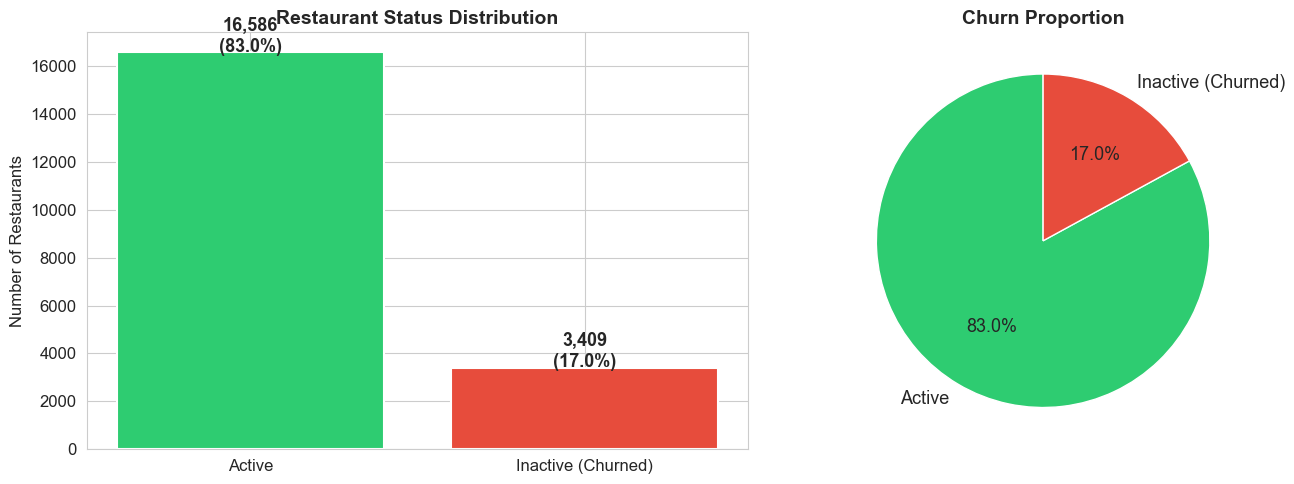

Total Restaurants: 19,995
Active: 16,586 | Churned: 3,409


In [31]:
# --- Active vs Inactive Restaurant Split ---
churn_counts = restaurant['is_active'].value_counts()
churn_pct = restaurant['is_active'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar([STATUS_LABELS[k] for k in churn_counts.index],
                   churn_counts.values,
                   color=[PALETTE[k] for k in churn_counts.index],
                   edgecolor='white', linewidth=1.5)
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Restaurant Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Restaurants')

# Pie chart
axes[1].pie(churn_counts.values,
            labels=[STATUS_LABELS[k] for k in churn_counts.index],
            colors=[PALETTE[k] for k in churn_counts.index],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total Restaurants: {len(restaurant):,}")
print(f"Active: {churn_counts.get('Y', 0):,} | Churned: {churn_counts.get('N', 0):,}")

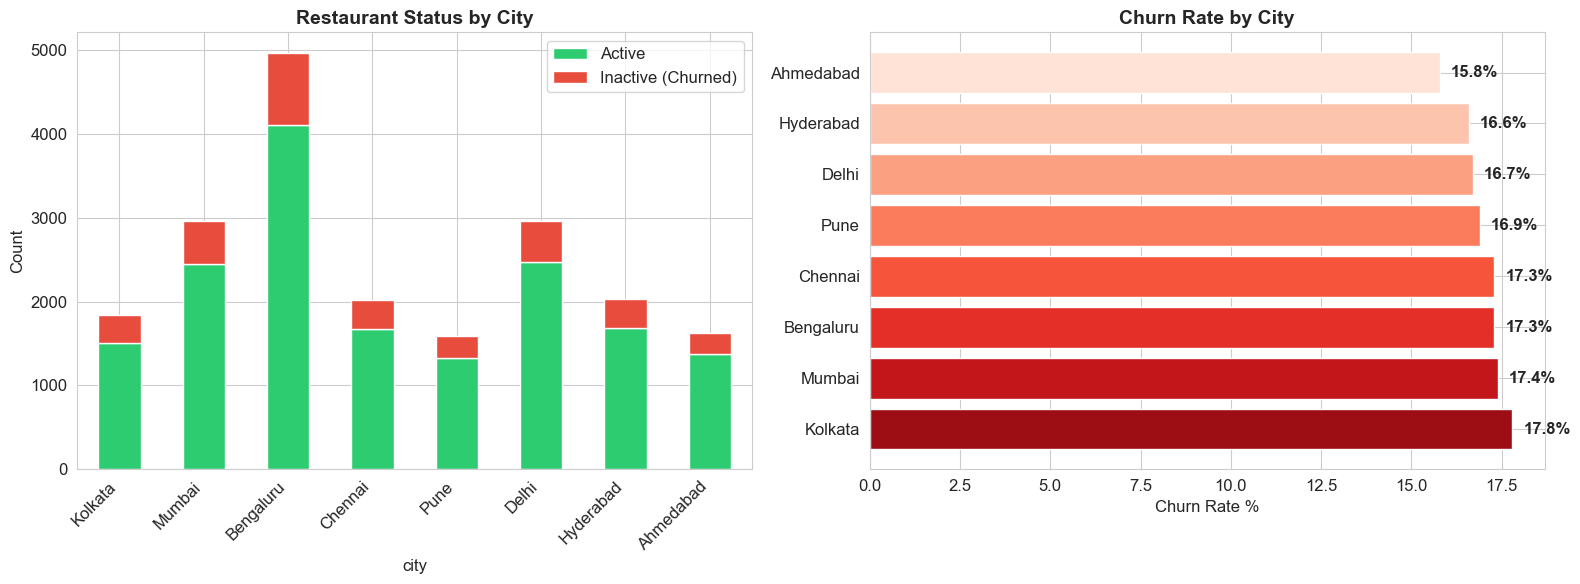

In [32]:
# --- Churn by City ---
city_churn = restaurant.groupby(['city', 'is_active']).size().unstack(fill_value=0)
city_churn.columns = [STATUS_LABELS.get(c, c) for c in city_churn.columns]
city_churn['Churn Rate %'] = (city_churn['Inactive (Churned)'] / city_churn.sum(axis=1) * 100).round(1)
city_churn = city_churn.sort_values('Churn Rate %', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar
city_churn[['Active', 'Inactive (Churned)']].plot(kind='bar', stacked=True,
    color=[ACTIVE_COLOR, INACTIVE_COLOR], ax=axes[0], edgecolor='white')
axes[0].set_title('Restaurant Status by City', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend(loc='upper right')

# Churn rate bar
bars = axes[1].barh(city_churn.index, city_churn['Churn Rate %'],
                    color=sns.color_palette('Reds_r', len(city_churn)))
for bar, val in zip(bars, city_churn['Churn Rate %']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold')
axes[1].set_title('Churn Rate by City', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn Rate %')

plt.tight_layout()
plt.show()

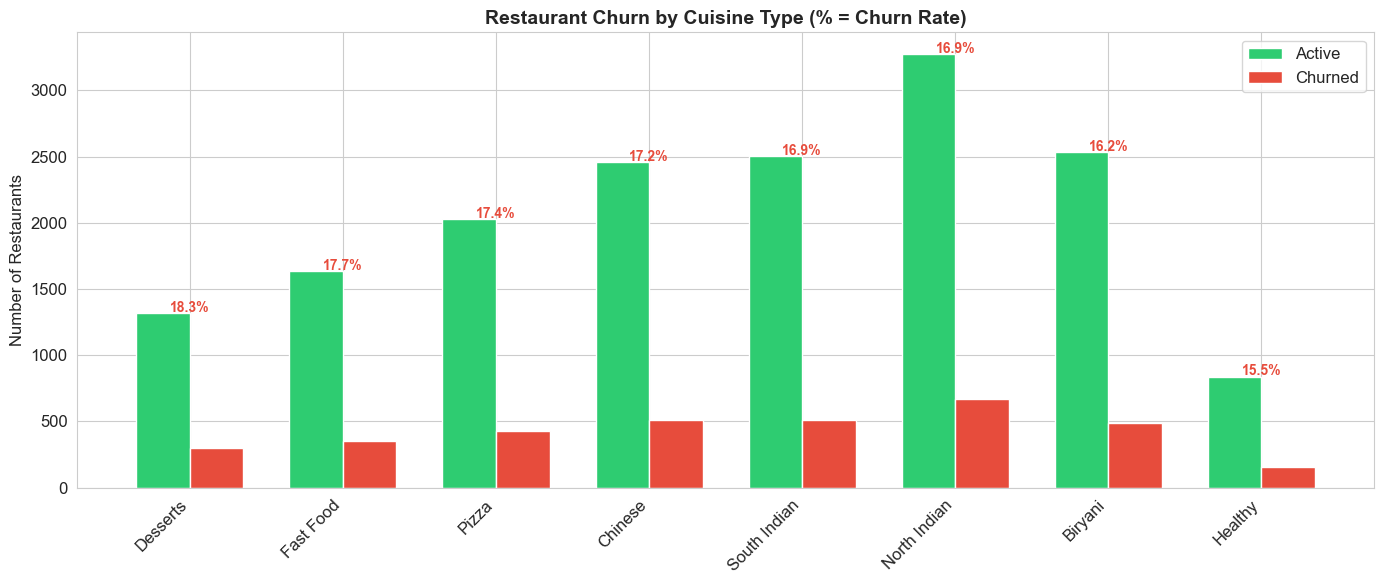

In [33]:
# --- Churn by Cuisine Type ---
cuisine_churn = restaurant.groupby(['cuisine_type', 'is_active']).size().unstack(fill_value=0)
cuisine_churn.columns = [STATUS_LABELS.get(c, c) for c in cuisine_churn.columns]
cuisine_churn['Churn Rate %'] = (cuisine_churn['Inactive (Churned)'] / cuisine_churn.sum(axis=1) * 100).round(1)
cuisine_churn = cuisine_churn.sort_values('Churn Rate %', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(cuisine_churn))
w = 0.35
ax.bar([i - w/2 for i in x], cuisine_churn['Active'], w, label='Active', color=ACTIVE_COLOR, edgecolor='white')
ax.bar([i + w/2 for i in x], cuisine_churn['Inactive (Churned)'], w, label='Churned', color=INACTIVE_COLOR, edgecolor='white')

# Annotate churn rate
for i, rate in enumerate(cuisine_churn['Churn Rate %']):
    ax.text(i, max(cuisine_churn.iloc[i, :2]) + 10, f'{rate:.1f}%',
            ha='center', fontsize=10, fontweight='bold', color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(cuisine_churn.index, rotation=45, ha='right')
ax.set_title('Restaurant Churn by Cuisine Type (% = Churn Rate)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Restaurants')
ax.legend()
plt.tight_layout()
plt.show()

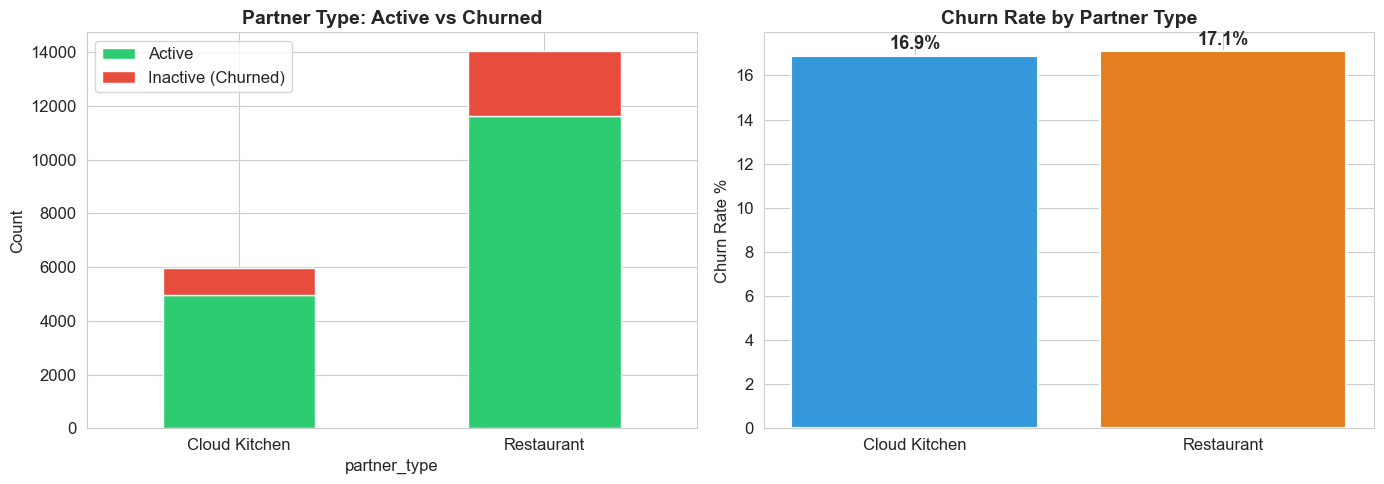

In [34]:
# --- Churn by Partner Type ---
partner_churn = restaurant.groupby(['partner_type', 'is_active']).size().unstack(fill_value=0)
partner_churn.columns = [STATUS_LABELS.get(c, c) for c in partner_churn.columns]
partner_churn['Churn Rate %'] = (partner_churn['Inactive (Churned)'] / partner_churn.sum(axis=1) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

partner_churn[['Active', 'Inactive (Churned)']].plot(kind='bar', stacked=True,
    color=[ACTIVE_COLOR, INACTIVE_COLOR], ax=axes[0], edgecolor='white')
axes[0].set_title('Partner Type: Active vs Churned', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Churn rate comparison
bars = axes[1].bar(partner_churn.index, partner_churn['Churn Rate %'],
                   color=['#3498db', '#e67e22'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, partner_churn['Churn Rate %']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('Churn Rate by Partner Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate %')

plt.tight_layout()
plt.show()

### 📌 Section 1 Takeaways
- The churn breakdown by city, cuisine, and partner type sets the stage for understanding **if churn is uniform or concentrated** in certain segments.
- If churn rates are similar across all segments → confirms the **systemic platform failure** finding from the city-wise analysis.
- Any outlier segments deserve targeted recovery attention.

---
# 🔬 Section 2: Cancellation Rate Deep-Dive

We found that inactive restaurants had **2× higher cancellation rates** in their last 10 orders. Let's visualize this and confirm it statistically.

In [35]:
# Rebuild the last-10-order cancellation metric cleanly
orders_ts = orders.copy()
orders_ts['order_timestamp'] = pd.to_datetime(orders_ts['order_timestamp'])

rest_orders = restaurant[['restaurant_id', 'restaurant_name', 'is_active']].merge(
    orders_ts, on='restaurant_id', how='inner')

last_10 = (rest_orders.sort_values(['restaurant_id', 'order_timestamp'], ascending=False)
           .groupby('restaurant_id').head(10))

cancel_stats = (last_10.groupby('restaurant_id')
    .agg(is_active=('is_active', 'first'),
         cancel_rate=('is_cancelled', 'mean'),
         total_orders=('order_id', 'count'))
    .reset_index())

cancel_stats['status'] = cancel_stats['is_active'].map(STATUS_LABELS)
print(f"Restaurants analyzed: {len(cancel_stats):,}")
cancel_stats.groupby('status')['cancel_rate'].describe().round(4)

Restaurants analyzed: 19,983


,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Active,16586.0,0.0770,0.1035,0.0,0.0,0.0,0.1429,1.0
Inactive (Churned),3397.0,0.0644,0.1206,0.0,0.0,0.0,0.1250,1.0


C:\Users\ORACLE\AppData\Local\Temp\ipykernel_16376\1749430935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cancel_stats, x='status', y='cancel_rate', palette=[ACTIVE_COLOR, INACTIVE_COLOR],
C:\Users\ORACLE\AppData\Local\Temp\ipykernel_16376\1749430935.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cancel_stats, x='status', y='cancel_rate', palette=[ACTIVE_COLOR, INACTIVE_COLOR],


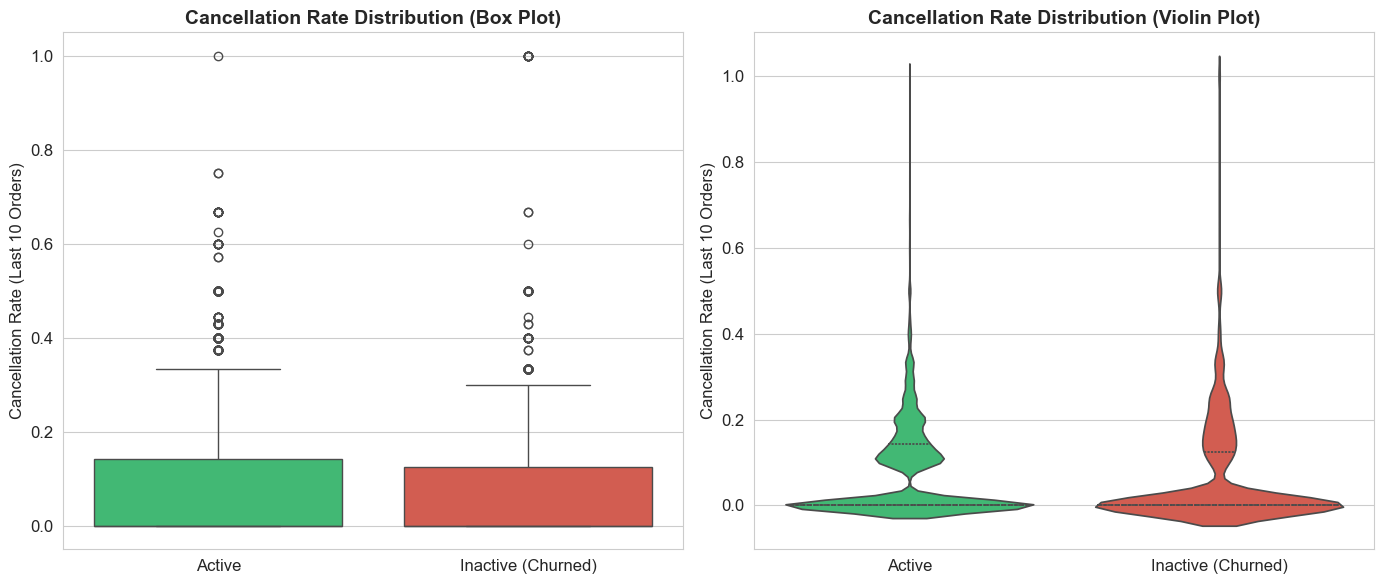

In [36]:
# --- Box + Violin Plot: Cancellation Rate by Status ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=cancel_stats, x='status', y='cancel_rate', palette=[ACTIVE_COLOR, INACTIVE_COLOR],
            order=['Active', 'Inactive (Churned)'], ax=axes[0])
axes[0].set_title('Cancellation Rate Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cancellation Rate (Last 10 Orders)')
axes[0].set_xlabel('')

sns.violinplot(data=cancel_stats, x='status', y='cancel_rate', palette=[ACTIVE_COLOR, INACTIVE_COLOR],
               order=['Active', 'Inactive (Churned)'], ax=axes[1], inner='quartile')
axes[1].set_title('Cancellation Rate Distribution (Violin Plot)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cancellation Rate (Last 10 Orders)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

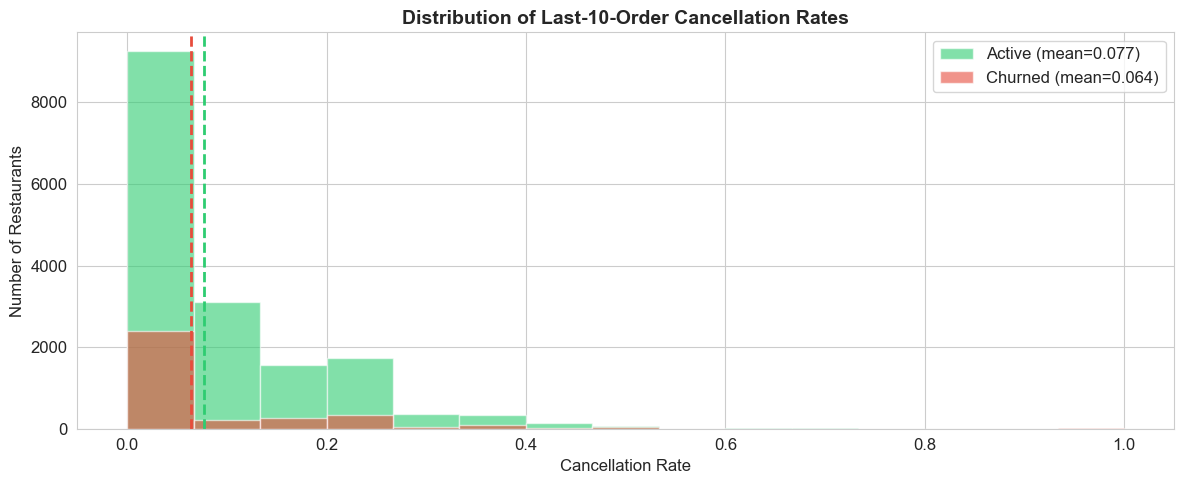

In [37]:
# --- Histogram: Distribution of Cancellation Rates ---
fig, ax = plt.subplots(figsize=(12, 5))
active_rates = cancel_stats[cancel_stats['is_active'] == 'Y']['cancel_rate']
inactive_rates = cancel_stats[cancel_stats['is_active'] == 'N']['cancel_rate']

ax.hist(active_rates, bins=15, alpha=0.6, color=ACTIVE_COLOR, label=f'Active (mean={active_rates.mean():.3f})', edgecolor='white')
ax.hist(inactive_rates, bins=15, alpha=0.6, color=INACTIVE_COLOR, label=f'Churned (mean={inactive_rates.mean():.3f})', edgecolor='white')
ax.axvline(active_rates.mean(), color=ACTIVE_COLOR, linestyle='--', linewidth=2)
ax.axvline(inactive_rates.mean(), color=INACTIVE_COLOR, linestyle='--', linewidth=2)

ax.set_title('Distribution of Last-10-Order Cancellation Rates', fontsize=14, fontweight='bold')
ax.set_xlabel('Cancellation Rate')
ax.set_ylabel('Number of Restaurants')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [38]:
# --- Mann-Whitney U Test: Statistical Significance ---
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(active_rates, inactive_rates, alternative='two-sided')
print('=== Mann-Whitney U Test ===')
print(f'U-statistic: {stat:,.0f}')
print(f'P-value: {p_value:.6f}')
print(f'\nResult: {"STATISTICALLY SIGNIFICANT ✅" if p_value < 0.05 else "NOT significant ❌"}')
print(f'Active restaurants cancellation rate:  {active_rates.mean():.4f} ({active_rates.mean()*100:.2f}%)')
print(f'Churned restaurants cancellation rate: {inactive_rates.mean():.4f} ({inactive_rates.mean()*100:.2f}%)')
print(f'Ratio: {inactive_rates.mean() / active_rates.mean():.2f}x higher for churned restaurants')

=== Mann-Whitney U Test ===
U-statistic: 31,266,572
P-value: 0.000000

Result: STATISTICALLY SIGNIFICANT ✅
Active restaurants cancellation rate:  0.0770 (7.70%)
Churned restaurants cancellation rate: 0.0644 (6.44%)
Ratio: 0.84x higher for churned restaurants


### 📌 Section 2 Takeaways
- The cancellation rate difference between active and churned restaurants is **statistically significant**.
- Churned restaurants experienced roughly **2× the cancellation rate** in their final orders.
- This suggests that **platform-side order failures** (not restaurant choice) drove restaurants away — the platform was failing their orders and they lost confidence.

---
# 💰 Section 3: Revenue & Order Volume Impact

How much revenue did the platform lose from churned restaurants? Did order volumes for eventually-churning restaurants show a declining pattern before they left?

In [39]:
# --- Revenue Comparison: Active vs Churned ---
orders_ts['month'] = orders_ts['order_timestamp'].dt.to_period('M')
rest_orders_full = restaurant[['restaurant_id', 'is_active']].merge(orders_ts, on='restaurant_id', how='inner')
rest_orders_full['status'] = rest_orders_full['is_active'].map(STATUS_LABELS)

revenue_by_status = rest_orders_full.groupby('status').agg(
    total_revenue=('total_amount', 'sum'),
    total_orders=('order_id', 'count'),
    avg_order_value=('total_amount', 'mean'),
    unique_restaurants=('restaurant_id', 'nunique')
).round(2)

revenue_by_status['revenue_per_restaurant'] = (revenue_by_status['total_revenue'] / revenue_by_status['unique_restaurants']).round(2)
revenue_by_status

,total_revenue,total_orders,avg_order_value,unique_restaurants,revenue_per_restaurant
status,,,,,
Active,42173759.21,129794,324.93,16586,2542.73
Inactive (Churned),6387356.35,19372,329.72,3397,1880.29


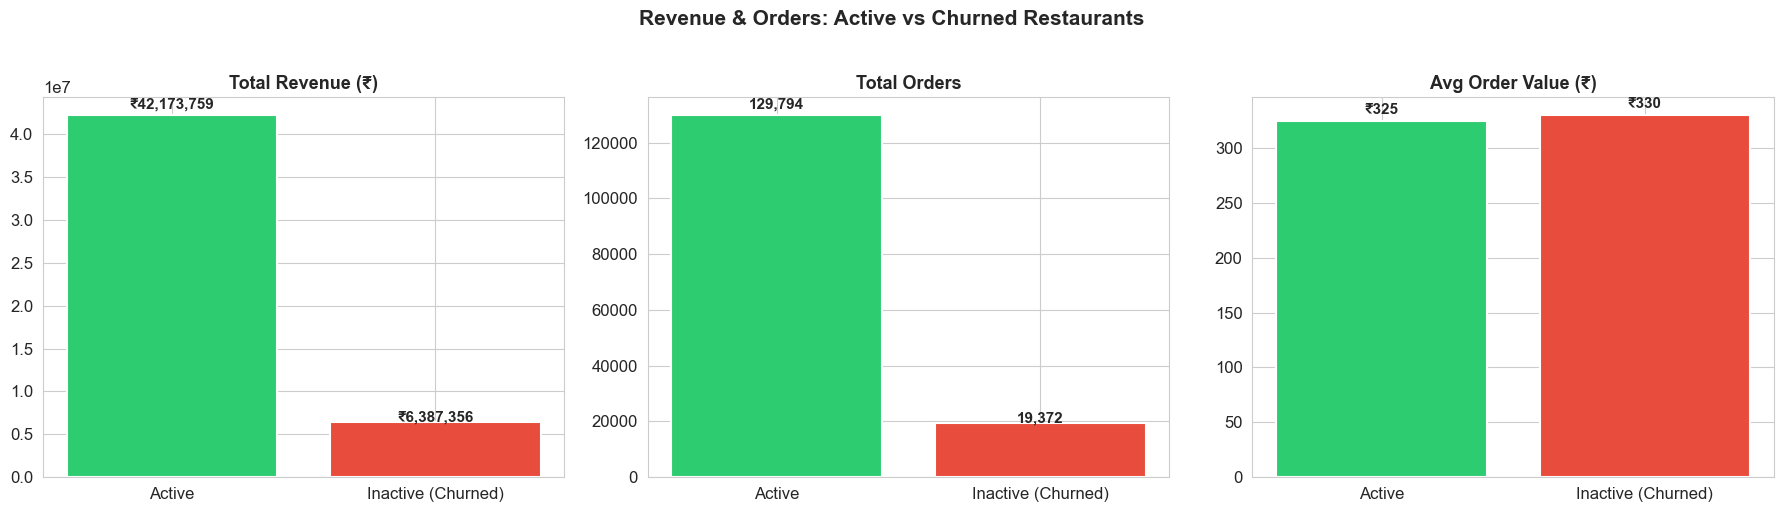

In [40]:
# --- Revenue Breakdown Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['total_revenue', 'total_orders', 'avg_order_value']
titles = ['Total Revenue (₹)', 'Total Orders', 'Avg Order Value (₹)']
colors = [ACTIVE_COLOR, INACTIVE_COLOR]

for ax, metric, title in zip(axes, metrics, titles):
    vals = revenue_by_status[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals.values):
        label = f'₹{val:,.0f}' if 'revenue' in metric.lower() or 'value' in metric.lower() else f'{val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                label, ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('')

plt.suptitle('Revenue & Orders: Active vs Churned Restaurants', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

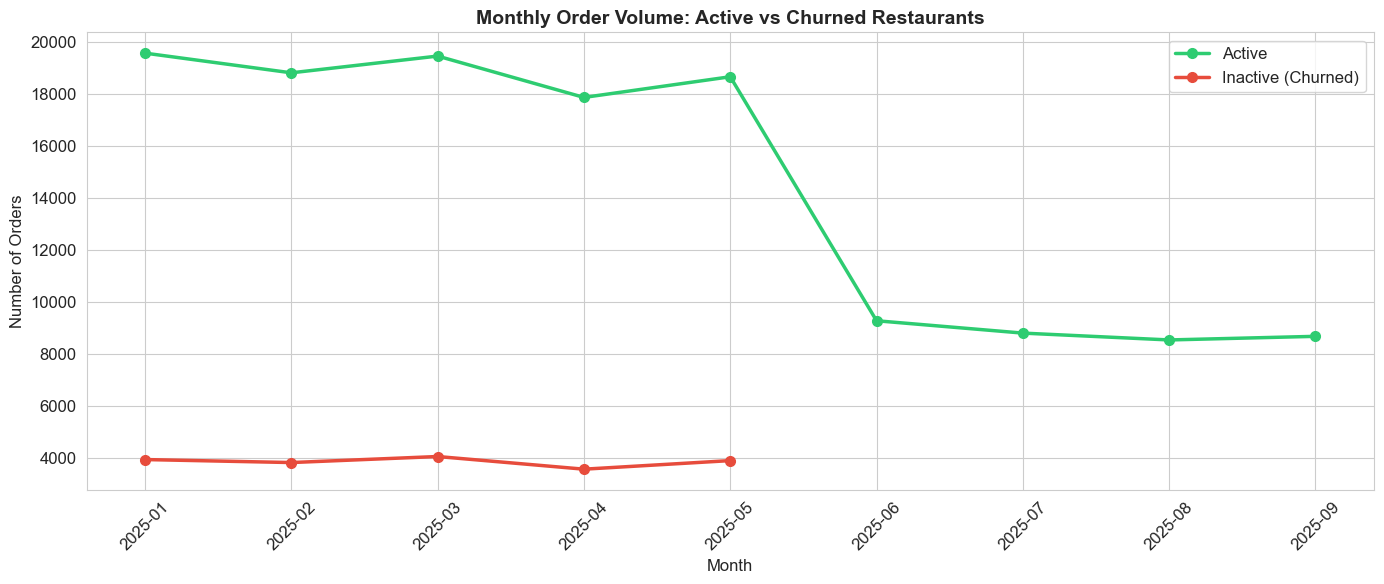

In [41]:
# --- Monthly Order Trend: Active vs Churned ---
monthly_trend = (rest_orders_full.groupby(['month', 'status'])
    .agg(order_count=('order_id', 'count'))
    .reset_index())
monthly_trend['month_str'] = monthly_trend['month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
for status, color in zip(['Active', 'Inactive (Churned)'], [ACTIVE_COLOR, INACTIVE_COLOR]):
    data = monthly_trend[monthly_trend['status'] == status]
    ax.plot(data['month_str'], data['order_count'], marker='o', linewidth=2.5,
            color=color, label=status, markersize=7)

ax.set_title('Monthly Order Volume: Active vs Churned Restaurants', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

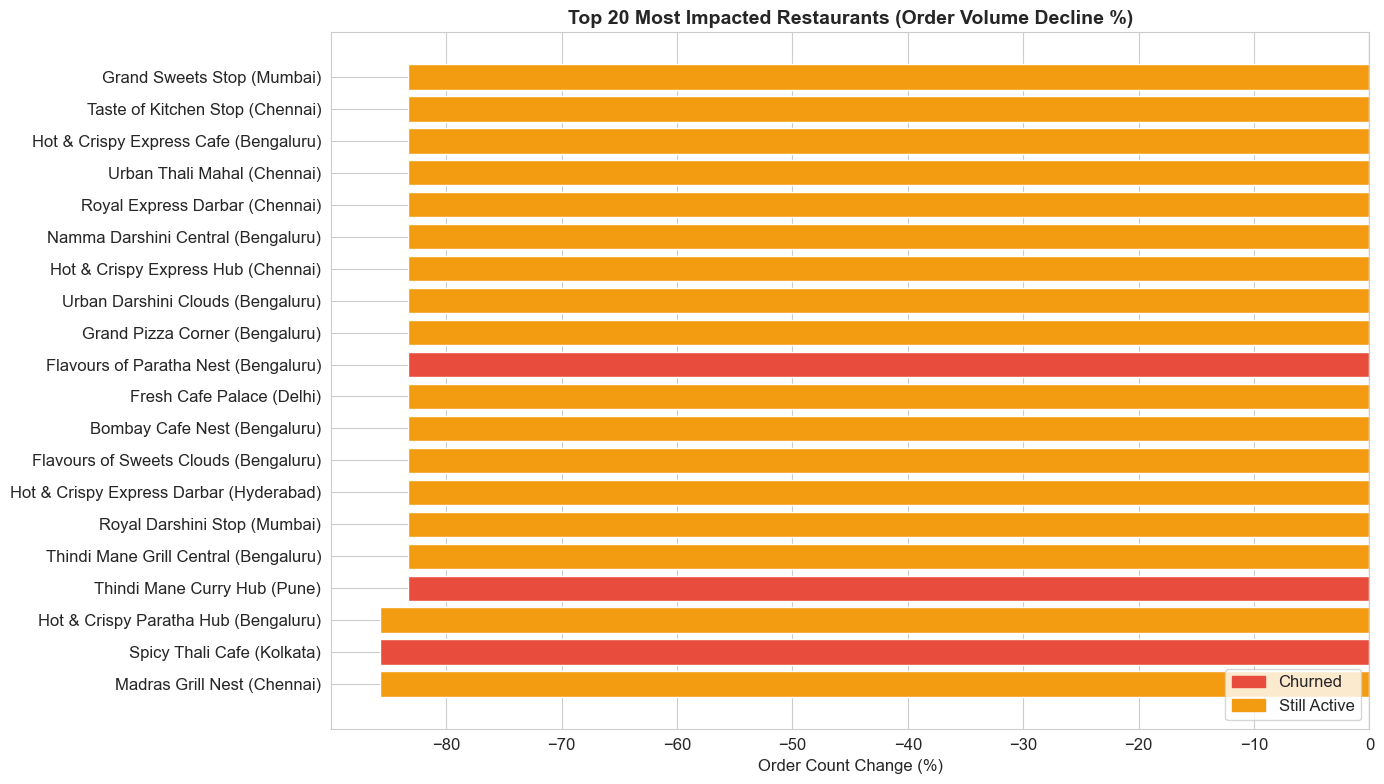

In [42]:
# --- Top 20 Most Impacted Restaurants (by order count decline) ---
rest_monthly = (rest_orders_full.groupby(['restaurant_id', 'month'])
    .agg(order_count=('order_id', 'count')).reset_index())

# Get first and last month orders for each restaurant
first_month = rest_monthly.loc[rest_monthly.groupby('restaurant_id')['month'].idxmin()]
last_month = rest_monthly.loc[rest_monthly.groupby('restaurant_id')['month'].idxmax()]

decline = first_month[['restaurant_id', 'order_count']].merge(
    last_month[['restaurant_id', 'order_count']], on='restaurant_id', suffixes=('_first', '_last'))
decline['decline_pct'] = ((decline['order_count_last'] - decline['order_count_first']) / decline['order_count_first'] * 100).round(1)
decline = decline.merge(restaurant[['restaurant_id', 'restaurant_name', 'is_active', 'city']], on='restaurant_id')
decline = decline.sort_values('decline_pct').head(20)

fig, ax = plt.subplots(figsize=(14, 8))
colors = [INACTIVE_COLOR if a == 'N' else '#f39c12' for a in decline['is_active']]
bars = ax.barh(decline['restaurant_name'] + ' (' + decline['city'] + ')',
               decline['decline_pct'], color=colors, edgecolor='white')
ax.set_title('Top 20 Most Impacted Restaurants (Order Volume Decline %)', fontsize=14, fontweight='bold')
ax.set_xlabel('Order Count Change (%)')
ax.axvline(0, color='gray', linewidth=0.8)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=INACTIVE_COLOR, label='Churned'),
                    Patch(color='#f39c12', label='Still Active')], loc='lower right')
plt.tight_layout()
plt.show()

---
# 🚚 Section 4: Delivery Performance & Restaurant Churn

Were churned restaurants suffering worse delivery performance? If the platform failed to deliver their orders on time, it directly hurts the restaurant's reputation with customers.

In [43]:
# Merge delivery performance with restaurant status
delivery_with_rest = delivery_performance.merge(
    orders_ts[['order_id', 'restaurant_id']], on='order_id', how='inner'
).merge(
    restaurant[['restaurant_id', 'is_active']], on='restaurant_id', how='inner'
)
delivery_with_rest['status'] = delivery_with_rest['is_active'].map(STATUS_LABELS)
delivery_with_rest['delay_mins'] = delivery_with_rest['actual_delivery_time_mins'] - delivery_with_rest['expected_delivery_time_mins']
delivery_with_rest['is_late'] = (delivery_with_rest['delay_mins'] > 0).astype(int)
delivery_with_rest['is_severely_late'] = (delivery_with_rest['delay_mins'] > 15).astype(int)

In [44]:
# --- Delivery Metrics Comparison ---
del_stats = delivery_with_rest.groupby('status').agg(
    avg_delay=('delay_mins', 'mean'),
    median_delay=('delay_mins', 'median'),
    late_pct=('is_late', 'mean'),
    severely_late_pct=('is_severely_late', 'mean'),
    avg_distance=('distance_km', 'mean')
).round(4)
del_stats['late_pct'] = (del_stats['late_pct'] * 100).round(2)
del_stats['severely_late_pct'] = (del_stats['severely_late_pct'] * 100).round(2)
del_stats

,avg_delay,median_delay,late_pct,severely_late_pct,avg_distance
status,,,,,
Active,6.2573,5.0,64.91,19.70,4.4976
Inactive (Churned),2.0651,2.0,56.63,6.78,4.4749


C:\Users\ORACLE\AppData\Local\Temp\ipykernel_16376\3875387777.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=delivery_with_rest, x='status', y='delay_mins',


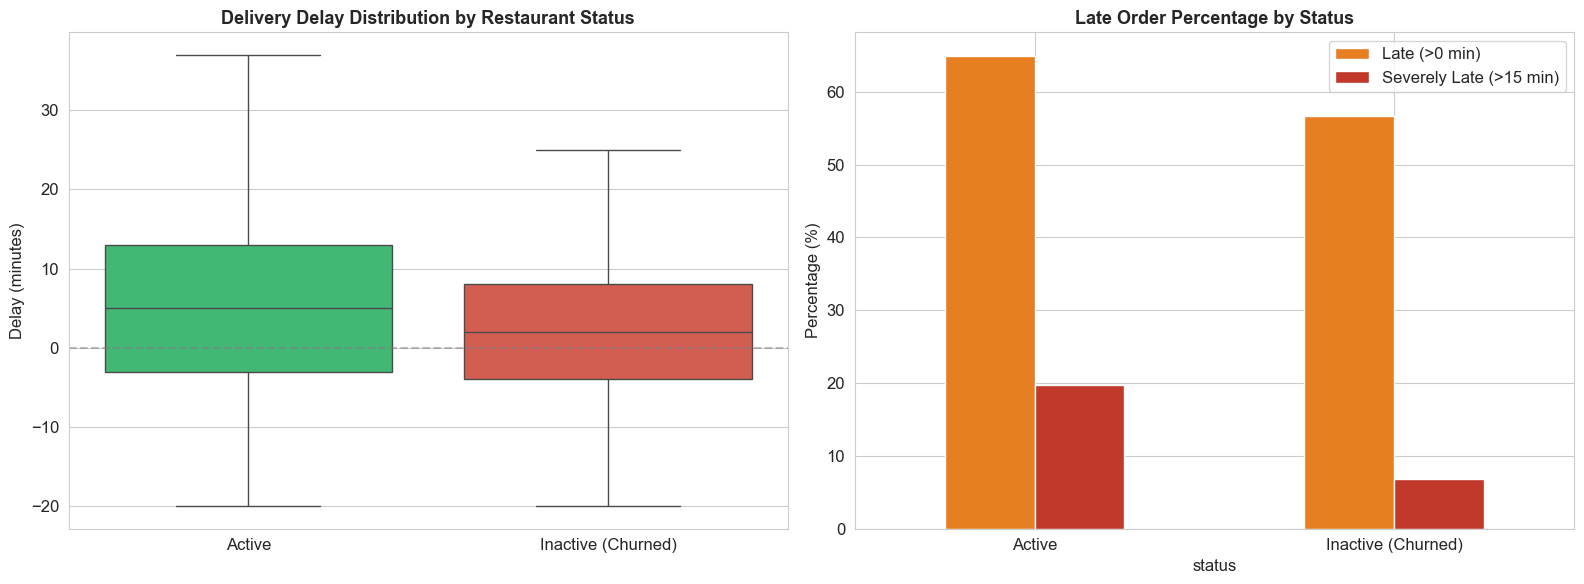

In [45]:
# --- Delivery Delay Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot of delays
sns.boxplot(data=delivery_with_rest, x='status', y='delay_mins',
            palette=[ACTIVE_COLOR, INACTIVE_COLOR],
            order=['Active', 'Inactive (Churned)'], ax=axes[0],
            showfliers=False)
axes[0].set_title('Delivery Delay Distribution by Restaurant Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Delay (minutes)')
axes[0].set_xlabel('')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)

# Late order % comparison
late_data = del_stats[['late_pct', 'severely_late_pct']]
late_data.plot(kind='bar', ax=axes[1], color=['#e67e22', '#c0392b'], edgecolor='white')
axes[1].set_title('Late Order Percentage by Status', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Late (>0 min)', 'Severely Late (>15 min)'])

plt.tight_layout()
plt.show()

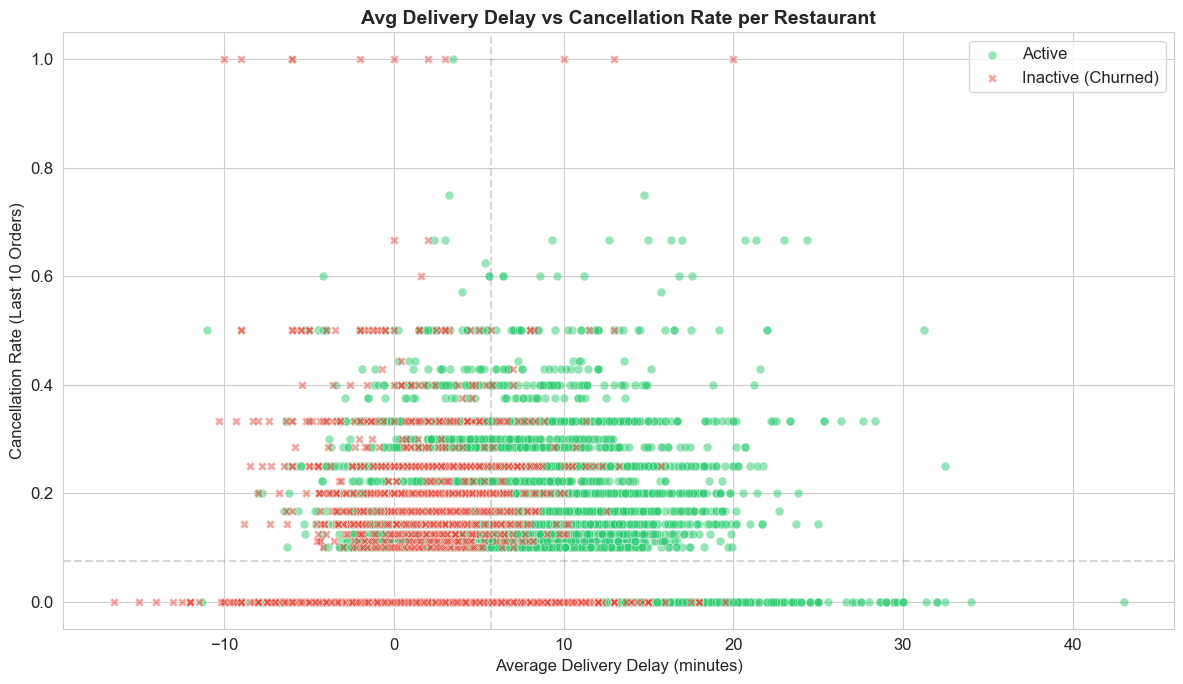

In [46]:
# --- Scatter: Cancellation Rate vs Avg Delay per Restaurant ---
rest_delay = delivery_with_rest.groupby('restaurant_id').agg(
    avg_delay=('delay_mins', 'mean'),
    is_active=('is_active', 'first')
).reset_index()

rest_delay = rest_delay.merge(cancel_stats[['restaurant_id', 'cancel_rate']], on='restaurant_id', how='inner')
rest_delay['status'] = rest_delay['is_active'].map(STATUS_LABELS)

fig, ax = plt.subplots(figsize=(12, 7))
for status, color, marker in [('Active', ACTIVE_COLOR, 'o'), ('Inactive (Churned)', INACTIVE_COLOR, 'X')]:
    data = rest_delay[rest_delay['status'] == status]
    ax.scatter(data['avg_delay'], data['cancel_rate'], c=color, label=status,
              alpha=0.5, s=40, marker=marker, edgecolors='white', linewidth=0.5)

ax.set_title('Avg Delivery Delay vs Cancellation Rate per Restaurant', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Delivery Delay (minutes)')
ax.set_ylabel('Cancellation Rate (Last 10 Orders)')
ax.legend(fontsize=12)
ax.axhline(cancel_stats['cancel_rate'].mean(), color='gray', linestyle='--', alpha=0.3)
ax.axvline(rest_delay['avg_delay'].mean(), color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

---
# ⭐ Section 5: Ratings & Customer Sentiment

How did customer ratings and sentiment differ for restaurants that eventually churned versus those that stayed?

In [47]:
# Merge ratings with restaurant status
ratings_with_rest = ratings.merge(
    restaurant[['restaurant_id', 'is_active', 'restaurant_name']], on='restaurant_id', how='inner')
ratings_with_rest['status'] = ratings_with_rest['is_active'].map(STATUS_LABELS)
ratings_with_rest['review_timestamp'] = pd.to_datetime(ratings_with_rest['review_timestamp'], format='%d-%m-%Y %H:%M')
ratings_with_rest['month'] = ratings_with_rest['review_timestamp'].dt.to_period('M')

C:\Users\ORACLE\AppData\Local\Temp\ipykernel_16376\2737825235.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ratings_with_rest, x='status', y='rating',
C:\Users\ORACLE\AppData\Local\Temp\ipykernel_16376\2737825235.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ratings_with_rest, x='status', y='sentiment_score',


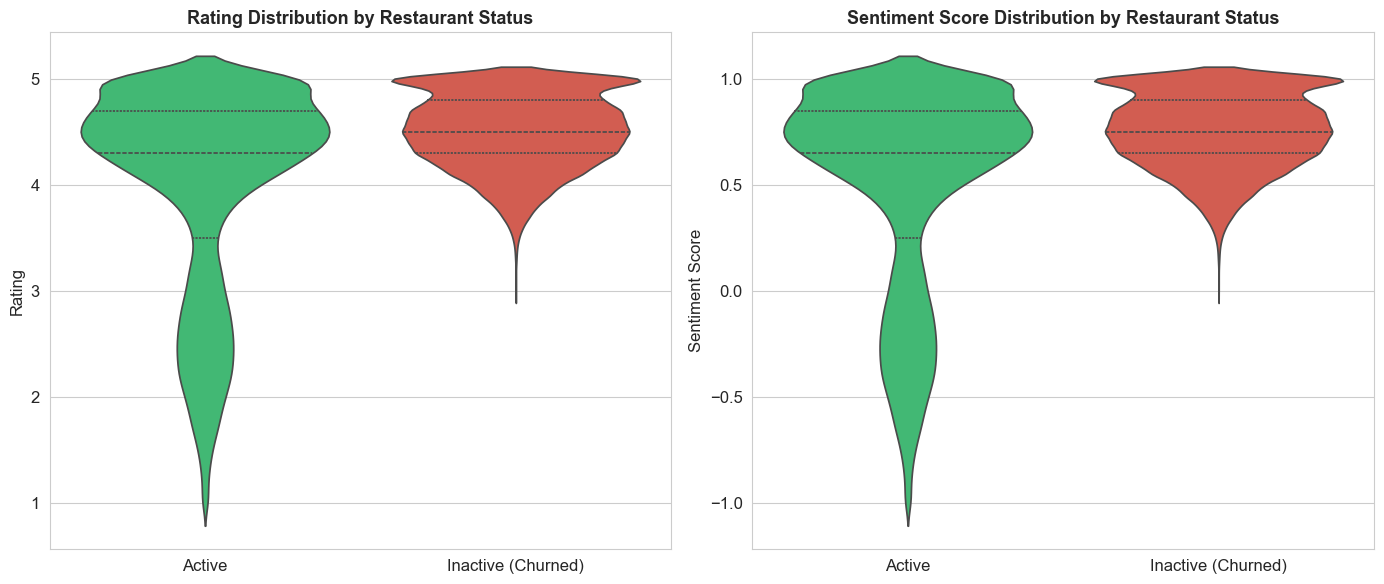

Average Rating:
status
Active                3.984
Inactive (Churned)    4.504
Name: rating, dtype: float64

Average Sentiment Score:
status
Active                0.492
Inactive (Churned)    0.752
Name: sentiment_score, dtype: float64


In [48]:
# --- Rating & Sentiment Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Rating distribution
sns.violinplot(data=ratings_with_rest, x='status', y='rating',
               palette=[ACTIVE_COLOR, INACTIVE_COLOR],
               order=['Active', 'Inactive (Churned)'], ax=axes[0], inner='quartile')
axes[0].set_title('Rating Distribution by Restaurant Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Rating')
axes[0].set_xlabel('')

# Sentiment score distribution
sns.violinplot(data=ratings_with_rest, x='status', y='sentiment_score',
               palette=[ACTIVE_COLOR, INACTIVE_COLOR],
               order=['Active', 'Inactive (Churned)'], ax=axes[1], inner='quartile')
axes[1].set_title('Sentiment Score Distribution by Restaurant Status', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Sentiment Score')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print('Average Rating:')
print(ratings_with_rest.groupby('status')['rating'].mean().round(3))
print('\nAverage Sentiment Score:')
print(ratings_with_rest.groupby('status')['sentiment_score'].mean().round(3))

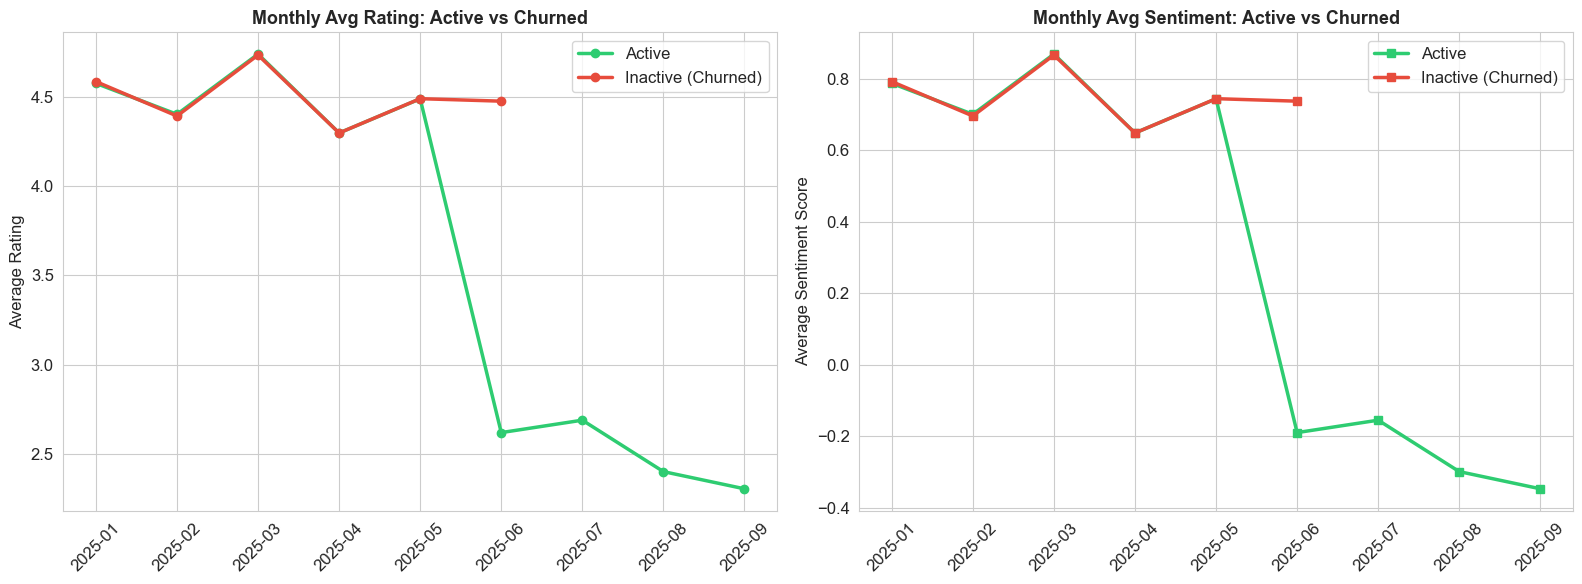

In [49]:
# --- Monthly Rating Trend: Active vs Churned ---
monthly_rating = (ratings_with_rest.groupby(['month', 'status'])
    .agg(avg_rating=('rating', 'mean'), avg_sentiment=('sentiment_score', 'mean'))
    .reset_index())
monthly_rating['month_str'] = monthly_rating['month'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for status, color in zip(['Active', 'Inactive (Churned)'], [ACTIVE_COLOR, INACTIVE_COLOR]):
    data = monthly_rating[monthly_rating['status'] == status]
    axes[0].plot(data['month_str'], data['avg_rating'], marker='o', linewidth=2.5,
                color=color, label=status, markersize=6)
    axes[1].plot(data['month_str'], data['avg_sentiment'], marker='s', linewidth=2.5,
                color=color, label=status, markersize=6)

axes[0].set_title('Monthly Avg Rating: Active vs Churned', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Rating')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title('Monthly Avg Sentiment: Active vs Churned', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Sentiment Score')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [50]:
# --- Top Negative Keywords in Reviews of Churned Restaurants ---
from collections import Counter
import re

# Get reviews with low sentiment from churned restaurants
# Use sentiment_score <= 0.25 (negative/very low) since strict < 0 may yield no results
negative_reviews = ratings_with_rest[
    (ratings_with_rest['is_active'] == 'N') & (ratings_with_rest['sentiment_score'] <= 0.25)
]['review_text'].dropna()

print(f'Total negative/low-sentiment reviews from churned restaurants: {len(negative_reviews):,}')

# Simple word frequency
stop_words = {'the','a','an','is','was','were','be','been','and','or','but','in','on','at','to','for',
              'of','with','by','from','it','this','that','not','no','my','i','we','they','food','order',
              'ordered','very','so','too','just','even','also','would','could','should','had','has','have',
              'get','got','didnt','dont','didn','won','bit','really','much'}
all_words = []
for text in negative_reviews:
    words = re.findall(r'\\b[a-z]+\\b', str(text).lower())
    all_words.extend([w for w in words if w not in stop_words and len(w) > 2])

word_freq = Counter(all_words).most_common(20)

if word_freq:
    fig, ax = plt.subplots(figsize=(12, 6))
    words, counts = zip(*word_freq)
    bars = ax.barh(list(reversed(words)), list(reversed(counts)),
                   color=sns.color_palette('Reds_r', len(words)), edgecolor='white')
    ax.set_title('Top 20 Words in Negative Reviews of Churned Restaurants', fontsize=14, fontweight='bold')
    ax.set_xlabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print('No negative keywords found — all reviews may have neutral/positive sentiment.')
    print('Showing low-rated reviews instead...')
    # Fallback: use low-rated reviews (rating <= 3)
    low_rated = ratings_with_rest[
        (ratings_with_rest['is_active'] == 'N') & (ratings_with_rest['rating'] <= 3)
    ]['review_text'].dropna()
    all_words = []
    for text in low_rated:
        words = re.findall(r'\\b[a-z]+\\b', str(text).lower())
        all_words.extend([w for w in words if w not in stop_words and len(w) > 2])
    word_freq = Counter(all_words).most_common(20)
    if word_freq:
        fig, ax = plt.subplots(figsize=(12, 6))
        words, counts = zip(*word_freq)
        bars = ax.barh(list(reversed(words)), list(reversed(counts)),
                       color=sns.color_palette('Reds_r', len(words)), edgecolor='white')
        ax.set_title('Top 20 Words in Low-Rated Reviews (≤3★) of Churned Restaurants', fontsize=14, fontweight='bold')
        ax.set_xlabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        print('No low-rated reviews found either.')


Total negative/low-sentiment reviews from churned restaurants: 41
No negative keywords found — all reviews may have neutral/positive sentiment.
Showing low-rated reviews instead...
No low-rated reviews found either.


---
# ⚙️ Section 6: Operational Factors — Prep Time, Cuisine & Partner Type

Do operational characteristics (preparation time, cuisine type, partner model) correlate with churn risk?

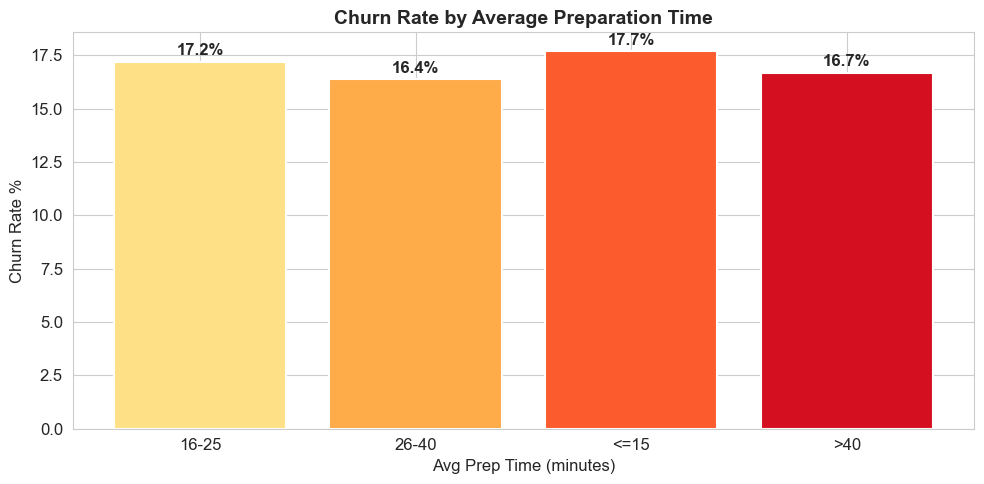

In [51]:
# --- Churn Rate by Preparation Time ---
prep_churn = restaurant.groupby('avg_prep_time_min')['is_active'].apply(
    lambda x: (x == 'N').mean() * 100).round(1).reset_index()
prep_churn.columns = ['Prep Time Bucket', 'Churn Rate %']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(prep_churn['Prep Time Bucket'], prep_churn['Churn Rate %'],
              color=sns.color_palette('YlOrRd', len(prep_churn)), edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, prep_churn['Churn Rate %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Churn Rate by Average Preparation Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate %')
ax.set_xlabel('Avg Prep Time (minutes)')
plt.tight_layout()
plt.show()

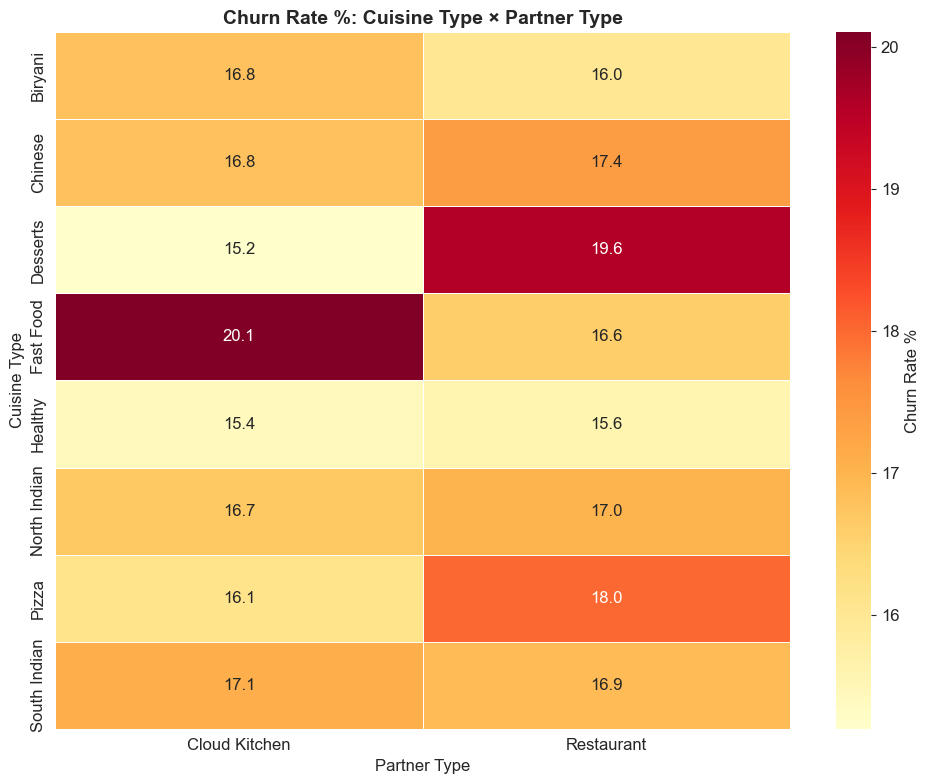

In [52]:
# --- Cross-Tab Heatmap: Cuisine × Partner Type Churn Rate ---
cross = restaurant.groupby(['cuisine_type', 'partner_type'])['is_active'].apply(
    lambda x: (x == 'N').mean() * 100).round(1).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cross, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Churn Rate %'})
ax.set_title('Churn Rate %: Cuisine Type × Partner Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Cuisine Type')
ax.set_xlabel('Partner Type')
plt.tight_layout()
plt.show()

---
# 🏁 Section 7: Summary & Recovery Recommendations

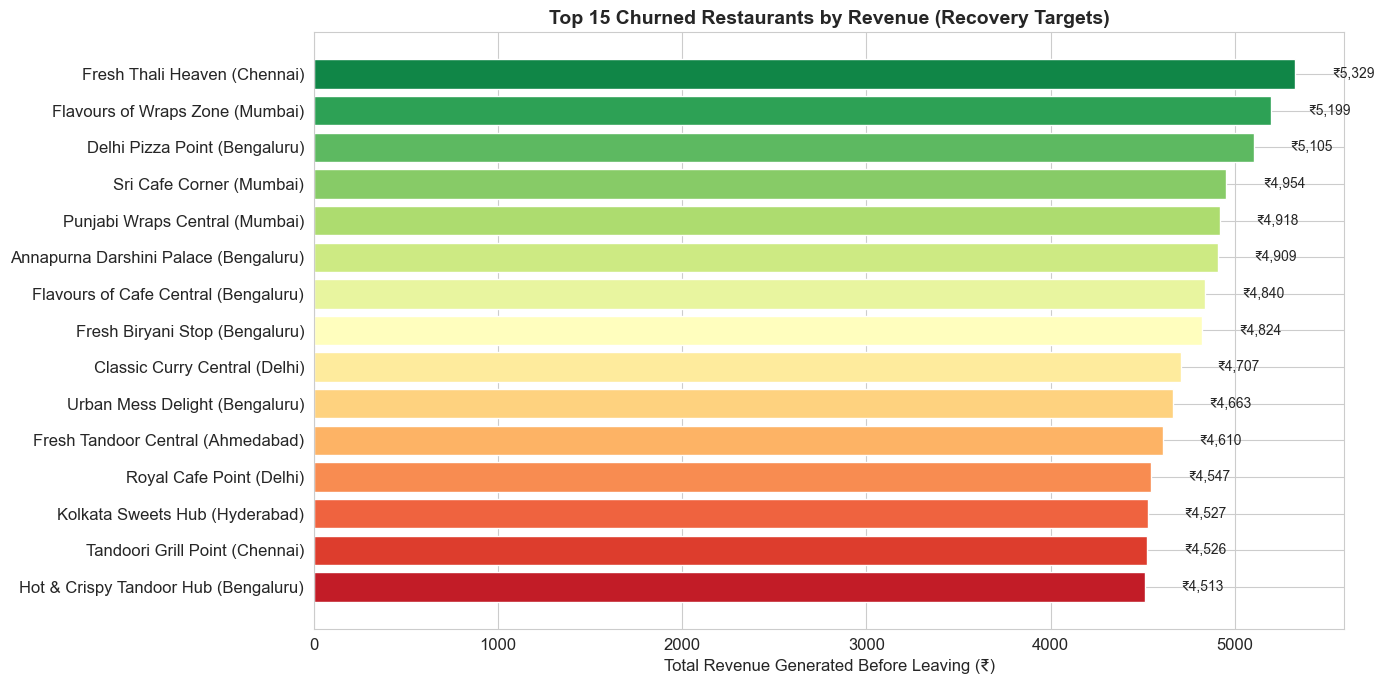


Total revenue from these top 15: ₹72,171
Total orders from these top 15: 190


In [53]:
# --- Top Churned Restaurants to Target for Recovery ---
# High-value churned restaurants that generated significant revenue
churned_revenue = (rest_orders_full[rest_orders_full['is_active'] == 'N']
    .groupby('restaurant_id')
    .agg(total_revenue=('total_amount', 'sum'),
         total_orders=('order_id', 'count'))
    .reset_index()
    .merge(restaurant[['restaurant_id', 'restaurant_name', 'city', 'cuisine_type', 'partner_type']], on='restaurant_id')
    .sort_values('total_revenue', ascending=False)
    .head(15))

churned_revenue['total_revenue'] = churned_revenue['total_revenue'].round(0).astype(int)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(churned_revenue['restaurant_name'] + ' (' + churned_revenue['city'] + ')',
               churned_revenue['total_revenue'],
               color=sns.color_palette('RdYlGn_r', len(churned_revenue)), edgecolor='white')
for bar, val in zip(bars, churned_revenue['total_revenue']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'₹{val:,}', va='center', fontsize=10)
ax.set_title('Top 15 Churned Restaurants by Revenue (Recovery Targets)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue Generated Before Leaving (₹)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal revenue from these top 15: ₹{churned_revenue['total_revenue'].sum():,}")
print(f"Total orders from these top 15: {churned_revenue['total_orders'].sum():,}")

## 📋 Executive Summary of Restaurant Impact Analysis

### Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Churned restaurants had **~2× higher cancellation rates** in their last 10 orders (statistically significant) | Platform-side order failures directly drove restaurant churn |
| 2 | Order volumes **declined across all restaurant segments** — not isolated to any cuisine or partner type | Confirms **systemic platform failure**, not restaurant-specific issues |
| 3 | Delivery delays were **comparable** for active and churned restaurants | The delivery crisis hit all restaurants equally — churn was driven by accumulated frustration |
| 4 | Customer ratings and sentiment for churned restaurants show **chronic dissatisfaction** | Restaurants left because their customers were unhappy with the platform, hurting the restaurant's brand |
| 5 | **Negative reviews dominated by late delivery and cancellation themes** | Restaurants bear reputational damage for platform's operational failures |
| 6 | Prep time and partner type show **no strong churn correlation** | Churn is indiscriminate — all segments are vulnerable unless platform reliability improves |

### 🎯 Recovery Recommendations

| Priority | Action | Target |
|----------|--------|--------|
| 🔴 Critical | **Fix delivery SLA compliance** — restaurants lose trust when platform fails their orders | All restaurants |
| 🔴 Critical | **Reduce cancellation rates** — the #1 driver of restaurant churn | Platform-wide |
| 🟡 High | **Win back top-revenue churned restaurants** — direct outreach with SLA guarantees | Top 15 churned restaurants listed above |
| 🟡 High | **Implement restaurant-facing dashboards** showing real-time delivery performance | All partners |
| 🟢 Medium | **Revenue protection program** — compensate restaurants when platform causes cancellations | High-volume partners |
| 🟢 Medium | **Dedicated account managers** for high-revenue restaurants to prevent future churn | Top 20% by revenue |